In [1]:
import math
import numpy as np
import pypulseq as pp
import matplotlib.pyplot as plt
from datetime import datetime
from types import SimpleNamespace

# System limits

## Siemens
system = pp.Opts(
    max_grad=24,
    grad_unit="mT/m",
    max_slew=180, # 90% de 188 T/(m*s)
    slew_unit="T/m/s",
    rf_ringdown_time=20e-6,
    rf_dead_time=100e-6,
    adc_dead_time=10e-6,
    grad_raster_time=10e-6
)

## Bruker 
system = pp.Opts(
    max_grad=300,
    grad_unit='mT/m',
    max_slew=2000,
    slew_unit='T/m/s',
    rf_ringdown_time=20e-6,
    rf_dead_time=100e-6,
    adc_dead_time=10e-6,
    grad_raster_time=10e-6 # should be 8 ?
)

In [2]:
# set system limits
system = pp.Opts(
    max_grad=300,
    grad_unit="mT/m",
    max_slew=2000, # 90% de 188 T/(m*s)
    slew_unit="T/m/s",
    rf_ringdown_time=20e-6,
    rf_dead_time=100e-6,
    adc_dead_time=10e-6,
    grad_raster_time=10e-6
)

In [3]:
version_sequence = "v1.0.1"

# --------------Important parameters--------------
# geometry
fov = np.array([30, 30, 0.8]) * 1e-3  # Define FOV (m)
N = [128, 128, 1] # nombre pixel

# Sequence
alpha_1 = 7  # Flip angle
alpha_2 = 7
ETL = 128

TI_1 = 0.8
TI_2 = 2.2
TR = 7e-3
TR_MP2RAGE = 5.0

# --------------Remaining various parameters--------------
# attention le dwell time doit être un multiple de 100ns
dwell = 20e-6
nDummy = 0

ro_os = 1  # Readout oversampling
ro_spoil = 3  # Additional k-max excursion for RO spoiling

rf_spoiling_inc = 117
rf_len = 2e-3 # second
dur_deph = 0.8e-3 # second
rf180_spoil_dur = 10e-3

In [4]:
# Cpmpute parameters
delta_k = 1 / fov
ro_dur =  dwell * N[0] # seconde  #5017.6e-6 # initial value
print("BW = {} Hz/pixel".format(1/ro_dur))
delta_k

BW = 390.62499999999994 Hz/pixel


array([  33.33333333,   33.33333333, 1250.        ])

# Create mask

In [5]:
mask = np.ones((1,N[1],N[2]))
np.shape(mask)

(1, 128, 1)

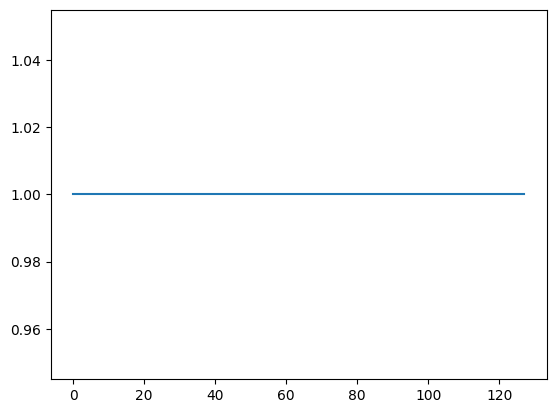

In [6]:
def disp(im, figsize=(4,4)): # to avoid code repetition
    if np.shape(mask)[2]==1:
        plt.plot(abs(np.squeeze(mask)))
    else:
        _, ax = plt.subplots(figsize=(4,4))
        ax.imshow(abs(np.squeeze(im)), cmap='gray')


disp(mask)


Generate ky,kz list

In [7]:
idx_bool = np.where(np.abs(mask) > 0)

In [8]:
def find_positive_values(array):
    row_indices = []
    column_indices = []
    
    for i in range(len(array)):
        for j in range(len(array[i])):
            if array[i][j] > 0:
                row_indices.append(i)
                column_indices.append(j)
    
    return row_indices, column_indices

row_indices, column_indices = find_positive_values(np.abs(mask[0,:,:]))
npoints=len(row_indices)
print("Row indices of positive values:", row_indices)
print("Column indices of positive values:", column_indices)
print("Number of points:", npoints)

Row indices of positive values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127]
Column indices of positive values: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Number of points:

nTR = 1 
npoints_crop = 128 


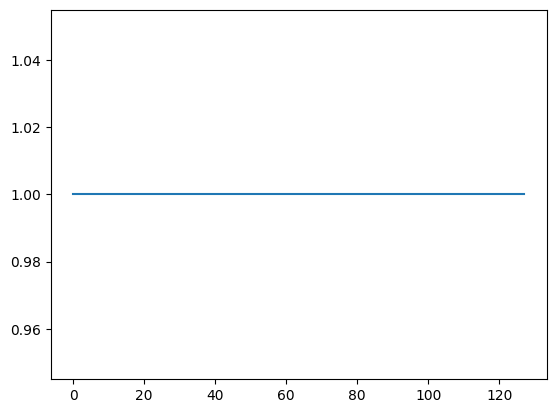

In [9]:
# Check that it works but first make it a modulo ETL
nTR = int(np.floor(npoints/ETL))
print("nTR = {} ".format(nTR))
npoints_crop=int(nTR*ETL)
print("npoints_crop = {} ".format(npoints_crop))

mask_verif = np.zeros(np.abs(mask[0,:,:]).shape,dtype=bool)
mask_verif[row_indices[0:npoints_crop-1],column_indices[0:npoints_crop-1]] = True
disp(mask)

In [10]:
print(npoints_crop)
print(np.shape(column_indices))
print(nTR)

128
(128,)
1


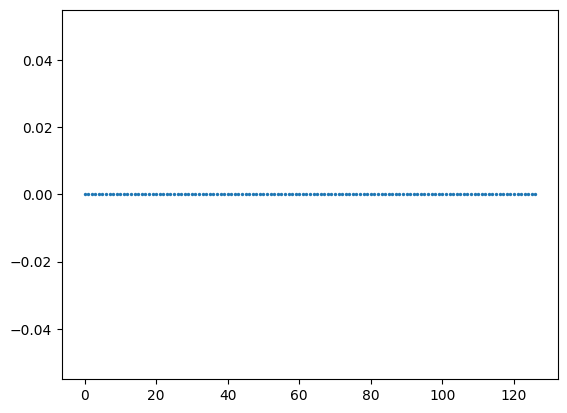

In [11]:
# Reorder to sample at TI
row_indices_reorder = np.zeros(np.shape(row_indices[0:npoints_crop]),dtype=int)
column_indices_reorder = np.zeros(np.shape(column_indices[0:npoints_crop]),dtype=int)

check_mask = np.zeros((N[1],N[2]))

idx = 0
for i in range(nTR):
    for j in range(ETL):
        
        row_indices_reorder[idx]=int(row_indices[j*nTR + i])
        column_indices_reorder[idx]=int(column_indices[j*nTR + i])

        check_mask[row_indices_reorder[idx],column_indices_reorder[idx]]=j
        idx = idx + 1

row_indices

# Check mask
#disp(check_mask)
for i in range(nTR):
    plt.scatter( row_indices_reorder[i*ETL:(i+1)*ETL-1],column_indices_reorder[i*ETL:(i+1)*ETL-1],s=2)
#row_indices_reorder[1]

# Define RF and gradient blocks

In [12]:
# Create alpha-degree slice selection pulse and gradient
rf_1, gz_1, _ = pp.make_sinc_pulse(
    flip_angle=alpha_1 * np.pi / 180,
    duration=rf_len,
    slice_thickness=fov[2],
    apodization=0.5,
    time_bw_product=4,
    system=system,
    return_gz=True,
)

rf_2, gz_2, _ = pp.make_sinc_pulse(
    flip_angle=alpha_2 * np.pi / 180,
    duration=rf_len,
    slice_thickness=fov[2],
    apodization=0.5,
    time_bw_product=4,
    system=system,
    return_gz=True,
)

# refocuse des selections de coupes
gz_1_reph = pp.make_trapezoid(
    channel="z", area=-gz_1.area / 2, system=system
)

gz_2_reph = pp.make_trapezoid(
    channel="z", area=-gz_2.area / 2, system=system
)

# Pulse d'inversion
#rf180 = pp.make_adiabatic_pulse(
#    pulse_type="hypsec", system=system, duration=10.0e-3, dwell=1e-5
#) #duration=10.24e-3
rf180 = pp.make_gauss_pulse(flip_angle=180 * np.pi / 180,   
     system=system, duration=10.0e-3
) #duration=10.24e-3

gz_rf180_spoil = pp.make_trapezoid(channel="z", area=4 * N[2] * delta_k[2],delay=pp.calc_duration(rf180),duration=rf180_spoil_dur, system=system)
pp.calc_duration(gz_rf180_spoil)


/var/folders/m1/88lfc1j95jvg1plm3bw_3kyr0000gp/T/ipykernel_64400/3235867668.py:2: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  rf_1, gz_1, _ = pp.make_sinc_pulse(
/var/folders/m1/88lfc1j95jvg1plm3bw_3kyr0000gp/T/ipykernel_64400/3235867668.py:12: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  rf_2, gz_2, _ = pp.make_sinc_pulse(
/var/folders/m1/88lfc1j95jvg1plm3bw_3kyr0000gp/T/ipykernel_64400/3235867668.py:35: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  rf180 = pp.make_gauss_pulse(flip_angle=180 * np.pi / 180,


0.02012

In [13]:
gro = pp.make_trapezoid(
    channel="x", flat_area=N[0] * delta_k[0], flat_time=ro_dur, system=system
)

adc = pp.make_adc(
    num_samples=N[0] * ro_os,
    duration=gro.flat_time,
    delay=gro.rise_time,
    system=system,
)

# dephasage 
gro_pre = pp.make_trapezoid(
    channel="x", area=-gro.area / 2, system=system
)

gpe1 = pp.make_trapezoid(
    channel="y", area=-delta_k[1] * (N[1] / 2),duration=dur_deph, system=system
)  # Maximum PE1 gradient

gpe2 = pp.make_trapezoid(
    channel="z", area=-delta_k[2] * (N[2] / 2),duration=dur_deph, system=system
)  # Maximum PE2 gradient

# Gradient spoiling # Spoil with 4x cycles per voxel
gx_spoil = pp.make_trapezoid(channel="x", area= N[0] * delta_k[0],system=system)

In [14]:
pp.calc_duration(gx_spoil)

0.00049

# Calculate Timing

In [15]:
# delay TR
delay_TR = TR - (np.maximum(pp.calc_duration(rf_1),pp.calc_duration(gz_1)) + 
  pp.calc_duration(gz_1_reph) +
  np.amax([pp.calc_duration(gro_pre),pp.calc_duration(gpe1),pp.calc_duration(gpe2)]) +
  pp.calc_duration(gro) +
  np.amax([pp.calc_duration(gx_spoil),pp.calc_duration(gpe1),pp.calc_duration(gpe2)])
  )

# delay gre
delay_gre1 = TI_1 - ( rf180_spoil_dur +  rf180.shape_dur/2 + system.rf_ringdown_time
  + (np.ceil(ETL/2)-1)*TR  #remove n/2-1 TR
  + rf_1.shape_dur/2 + system.rf_dead_time) #center TI at rf pulse

delay_gre2 = TI_2 - (TI_1 + ETL*TR)
#( ETL*TR + delay_gre1 + pp.calc_duration(rf180)/2 + pp.calc_duration(gz_rf180_spoil) )

delay_MP2RAGE = TR_MP2RAGE - ( TI_2 
                              - ((np.ceil(ETL/2)-1)*TR + rf_2.shape_dur/2 + system.rf_dead_time) # retour début GRE2
                              + ETL*TR # retour fin GRE2
                              + rf180.shape_dur/2 + system.rf_dead_time)
delay_MP2RAGE

np.float64(2.3409999999999997)

In [16]:
TR - delay_TR

np.float64(0.00668)

In [17]:
assert delay_TR > 0, ("TR is too short -> minimum TR ={} s".format(TR-delay_TR))

# Preparation phase encoding

In [18]:
pe1_steps = ((np.arange(N[1])) - np.ceil(N[1] / 2) + 1)/(N[1]/2)
pe2_steps = ((np.arange(N[2])) - np.ceil(N[2] / 2) + 1)/(N[2]/2)
pe1_steps

array([-0.984375, -0.96875 , -0.953125, -0.9375  , -0.921875, -0.90625 ,
       -0.890625, -0.875   , -0.859375, -0.84375 , -0.828125, -0.8125  ,
       -0.796875, -0.78125 , -0.765625, -0.75    , -0.734375, -0.71875 ,
       -0.703125, -0.6875  , -0.671875, -0.65625 , -0.640625, -0.625   ,
       -0.609375, -0.59375 , -0.578125, -0.5625  , -0.546875, -0.53125 ,
       -0.515625, -0.5     , -0.484375, -0.46875 , -0.453125, -0.4375  ,
       -0.421875, -0.40625 , -0.390625, -0.375   , -0.359375, -0.34375 ,
       -0.328125, -0.3125  , -0.296875, -0.28125 , -0.265625, -0.25    ,
       -0.234375, -0.21875 , -0.203125, -0.1875  , -0.171875, -0.15625 ,
       -0.140625, -0.125   , -0.109375, -0.09375 , -0.078125, -0.0625  ,
       -0.046875, -0.03125 , -0.015625,  0.      ,  0.015625,  0.03125 ,
        0.046875,  0.0625  ,  0.078125,  0.09375 ,  0.109375,  0.125   ,
        0.140625,  0.15625 ,  0.171875,  0.1875  ,  0.203125,  0.21875 ,
        0.234375,  0.25    ,  0.265625,  0.28125 , 

# Write sequence blocks

In [19]:
# definition label
label_inc_lin = pp.make_label(type="INC", label="LIN", value=1)
label_res_lin = pp.make_label(type="SET", label="LIN", value=0)

label_inc_par = pp.make_label(type="INC", label="PAR", value=1)
label_res_par = pp.make_label(type="SET", label="PAR", value=0)

label_set_TI1 = pp.make_label(type="SET", label="ECO", value=0)
label_set_TI2 = pp.make_label(type="SET", label="ECO", value=1)

# sequence
seq=pp.Sequence()
n_TR = 0

for iTR in range(nTR + nDummy):
  # init
  rf_1_phase = 0
  rf_1_inc = 0
  
  seq.add_block(rf180,gz_rf180_spoil,label_set_TI1)
  seq.add_block(pp.make_delay(delay_gre1))

  ## ETL 1
  for iTI in range(2):
    for i in range(ETL):
      mdh_ky = int(row_indices_reorder[i+n_TR*ETL])
      mdh_kz = int(column_indices_reorder[i+n_TR*ETL])

      label_set_lin = pp.make_label(type="SET", label="LIN", value=mdh_ky)
      label_set_par = pp.make_label(type="SET", label="PAR", value=mdh_kz)

      # RF spoiling
      rf_1.phase_offset = rf_1_phase / 180 * np.pi
      rf_2.phase_offset = rf_1_phase / 180 * np.pi
      adc.phase_offset = rf_1_phase / 180 * np.pi
      rf_1_inc = np.mod(rf_1_inc + rf_spoiling_inc, 360.0)
      rf_1_phase = np.mod(rf_1_phase + rf_1_inc, 360.0)

      if iTI==0:
        seq.add_block(rf_1,gz_1)
      else:
        seq.add_block(rf_2,gz_2)

      seq.add_block(gz_1_reph,label_set_lin,label_set_par)
      seq.add_block(gro_pre,pp.scale_grad(grad=gpe1, scale=pe1_steps[row_indices_reorder[i+n_TR*ETL]]),pp.scale_grad(grad=gpe2, scale=pe2_steps[column_indices_reorder[i+n_TR*ETL]]))
      
      if (iTR < nDummy):
        seq.add_block(gro)
      else:
        seq.add_block(gro,adc)

      seq.add_block(gx_spoil,pp.scale_grad(grad=gpe1, scale=-pe1_steps[row_indices_reorder[i+n_TR*ETL]]),pp.scale_grad(grad=gpe2, scale=-pe2_steps[column_indices_reorder[i+n_TR*ETL]])) 
      seq.add_block(pp.make_delay(delay_TR))

    # reset label
    if iTI==0:
        seq.add_block(pp.make_delay(delay_gre2),label_set_TI2) 
    
  seq.add_block(pp.make_delay(delay_MP2RAGE))

  if (iTR >= nDummy):
    n_TR = n_TR + 1

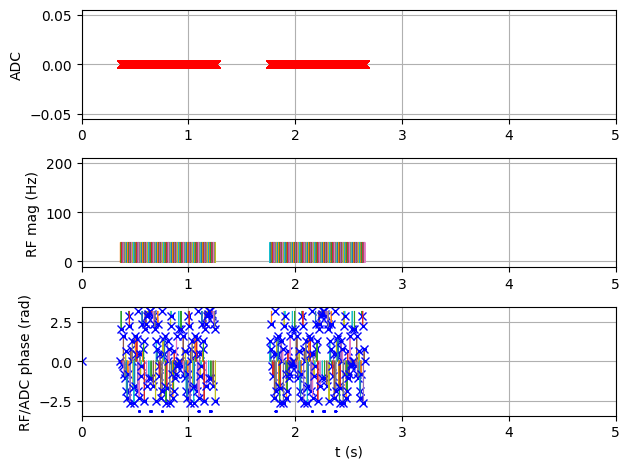

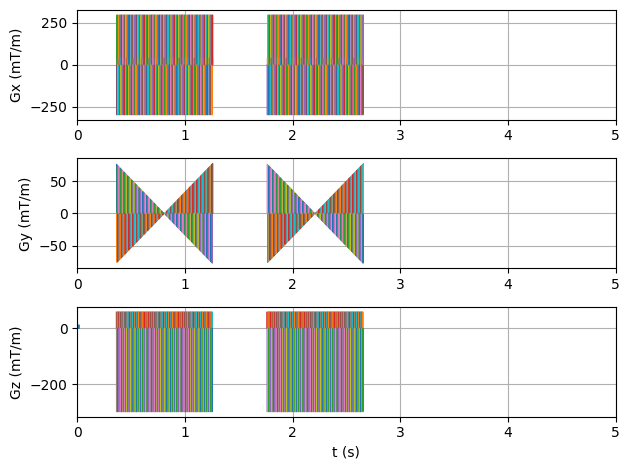

In [21]:
#seq.plot(time_range=[0.8,0.9],grad_disp="mT/m")
#%matplotlib widget
%matplotlib inline

#seq.plot(grad_disp="mT/m",time_range=(TI_2-0.010,TI_2+0.010),show_blocks=True,time_disp="s",label="LIN,PAR")
#seq.plot(grad_disp="mT/m",time_range=(nDummy*TR_MP2RAGE,(nDummy+2)*TR_MP2RAGE),show_blocks=False,time_disp="s",label="LIN,PAR")

seq.plot(grad_disp="mT/m",time_range=(0.0,800),show_blocks=False,time_disp="s")

# Check timing from blocks
for **TR**

In [22]:
dur=0
for block_counter in range(3,8+1,1):
  #print(block_counter)
  dur = dur + seq.get_block(block_counter).block_duration

print(dur)
assert np.abs(dur-TR) < 0.000000001, ("TR is not good")

0.007


for **TI1**

In [23]:
dur=0
for block_counter in range(1,round((2+(np.ceil(ETL/2)-1)*6)+ 1),1):
  #print(block_counter)
  dur = dur + seq.get_block(block_counter).block_duration

# add dur to exc
dur = dur + system.rf_dead_time + rf_1.shape_dur/2
# remove half inv + dead
dur = dur - system.rf_dead_time - rf180.shape_dur/2
print(dur)
assert np.abs(dur-TI_1) < 0.000000001, ("TI_1 is not good")

0.8000000000000016


for **TI2**

In [24]:
dur=0
for block_counter in range(1,round((2+ ETL*6 + 1 + (np.ceil(ETL/2)-1)*6)+ 1),1):
  #print(block_counter)
  dur = dur + seq.get_block(block_counter).block_duration

# add dur to exc
dur = dur + system.rf_dead_time + rf_1.shape_dur/2
# remove half inv + dead
dur = dur - system.rf_dead_time - rf180.shape_dur/2
print(dur)
assert np.abs(dur-TI_2) < 0.000000001, ("TI_2 is not good")

2.1999999999999975


for **TR_MP2RAGE**

In [25]:
dur=0
for block_counter in range(1,round(2+ ETL*6 + 1 + ETL*6 + 1 +1),1):
  #print(block_counter)
  dur = dur + seq.get_block(block_counter).block_duration
print(dur)
assert np.abs(dur-TR_MP2RAGE) < 0.000000001, ("TR_MP2RAGE is not good")

5.000000000000005


# Write sequence .seq

In [26]:
seq.check_timing()

(True, [])

## Parameters to store
```
version_sequence = "v1.0.0"

# --------------Important parameters--------------
# geometry
fov = np.array([350, 350, 3]) * 1e-3  # Define FOV (m)
N = [256, 256, 1] # nombre pixel

# Sequence
alpha_1 = 7  # Flip angle
alpha_2 = 7
ETL = 128

TI_1 = 0.8
TI_2 = 2.2
TR = 7e-3
TR_MP2RAGE = 5.0

accY = 1.4
accZ = 1.4

# --------------Remaining various parameters--------------
# attention le dwell time doit être un multiple de 100ns
dwell = 5e-6
ro_dur =  dwell * N[0] # seconde  #5017.6e-6 # initial value

print("BW = {} Hz/pixel".format(1/ro_dur))
ro_os = 1  # Readout oversampling
ro_spoil = 3  # Additional k-max excursion for RO spoiling

rf_spoiling_inc = 117
rf_len = 2e-3 # second
dur_deph = 0.8e-3 # second
rf180_spoil_dur = 10e-3
```

In [27]:
seq.set_definition("Name","MP2RAGE_CS_"+version_sequence)
seq.set_definition("version_sequence",version_sequence)
# System parameters
seq.set_definition("max_grad",system.max_grad)
seq.set_definition("max_slew",system.max_slew)
seq.set_definition("rf_ringdown_time",system.rf_ringdown_time)
seq.set_definition("rf_dead_time",system.rf_dead_time)
seq.set_definition("adc_dead_time",system.adc_dead_time)
seq.set_definition("AdcDeadTime",system.adc_dead_time)

# editable parameters
seq.set_definition("FOV",fov)
seq.set_definition("matrix",N)

seq.set_definition("TI_1",TI_1)
seq.set_definition("TI_2",TI_2)
seq.set_definition("small_TR",TR)
seq.set_definition("TR_MP2RAGE",TR_MP2RAGE)
seq.set_definition("ETL",ETL)
seq.set_definition("alpha_1",alpha_1)
seq.set_definition("alpha_2",alpha_2)


## param supp
seq.set_definition("nDummy",nDummy)
seq.set_definition("dwell",dwell)
seq.set_definition("ro_os",ro_os)
seq.set_definition("ro_spoil",ro_spoil)
seq.set_definition("rf_spoiling_inc",rf_spoiling_inc)
seq.set_definition("rf_len",rf_len)
seq.set_definition("dur_deph",rf_spoiling_inc)
seq.set_definition("rf180_spoil_dur",rf180_spoil_dur)

# param faciliter la reco
nAccel = N[1]*N[2]/np.size(row_indices_reorder)
seq.set_definition("nAccel",nAccel)


In [28]:
now = datetime.now()
dt_string = now.strftime("%Y%m%d_%Hh%Mm")
print("date and time =", dt_string)

#seq.write("UTE_"+version_sequence+"_"+dt_string+".seq") # SEQUENCE SANS TRAJ POUR SIEMENS
seq.write("out/bruker_MP2RAGE_PAR"+str(round(N[2]))) # SEQUENCE SANS TRAJ POUR SIEMENS


date and time = 20260529_10h46m


'85c5df940081abdddd2502ffe073ca46'